In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

In [2]:
with open("data/train.pkl", "rb") as file:
    X_train = pickle.load(file).reset_index()

Pasuje pozamieniać znaki, które dolegają do słów na puste stingi

In [3]:
X_train["Message"] = X_train["Message"].str.replace(",", " ")
X_train["Message"] = X_train["Message"].str.replace("\n", " ")

In [4]:
#help(x.str.replace)

In [5]:
X_train.head()

,index,Status,Message
0,2870,0,From ilug-admin@linux.ie Thu Aug 29 16:42:34 ...
1,13153,0,From rssfeeds@jmason.org Thu Sep 26 16:43:26 ...
2,4278,0,From spamassassin-talk-admin@lists.sourceforge...
3,4038,2,From jm@netnoteinc.com Mon Jul 29 11:22:06 20...
4,774,0,From fork-admin@xent.com Mon Sep 23 15:00:49 ...


In [6]:
np.mean(X_train["Message"].str.split(" ").str[1].str.contains("@"))

np.float64(0.9781708694015807)

In [7]:
email = X_train["Message"].str.split(" ")

In [8]:
email_2 = email.apply(lambda x: x[np.argmax(np.char.lower(np.array(x)) == "from") + 1])

In [9]:
email_2.head(30)

0                                   ilug-admin@linux.ie
1                                   rssfeeds@jmason.org
2         spamassassin-talk-admin@lists.sourceforge.net
3                                     jm@netnoteinc.com
4                                   fork-admin@xent.com
5                                   fork-admin@xent.com
6                              iqsoftware@export2000.ro
7                                   fork-admin@xent.com
8                          rpm-list-admin@freshrpms.net
9     secprog-return-491-jm=jmason.org@securityfocus...
10                                  fork-admin@xent.com
11                              abv-sfo-acmta2.cnet.com
12                         rpm-list-admin@freshrpms.net
13                                alerts@action.eff.org
14                            vi1teri6d3682@hotmail.com
15        spamassassin-talk-admin@lists.sourceforge.net
16                                  fork-admin@xent.com
17                                  rssfeeds@jma

In [10]:
email_2.tail(30)

10598                              ilug-admin@linux.ie
10599                              rssfeeds@jmason.org
10600         freshmeat-news-admin@lists.freshmeat.net
10601                    exmh-workers-admin@redhat.com
10602                    exmh-workers-admin@redhat.com
10603          razor-users-admin@lists.sourceforge.net
10604                     rpm-list-admin@freshrpms.net
10605                              fork-admin@xent.com
10606                           emailharvest@email.com
10607                              ilug-admin@linux.ie
10608                              rssfeeds@jmason.org
10609                              rssfeeds@jmason.org
10610                              ilug-admin@linux.ie
10611    spamassassin-talk-admin@lists.sourceforge.net
10612                      allmerica@insurancemail.net
10613                              fork-admin@xent.com
10614                              rssfeeds@jmason.org
10615                              fork-admin@xent.com
10616     

In [11]:
temp = email_2.str.split("@")

In [12]:
email_2 = pd.DataFrame(email_2)

In [13]:
email_2

,Message
0,ilug-admin@linux.ie
1,rssfeeds@jmason.org
2,spamassassin-talk-admin@lists.sourceforge.net
3,jm@netnoteinc.com
4,fork-admin@xent.com
...,...
10623,fork-admin@xent.com
10624,marninainj@chel.elektra.ru
10625,fork-admin@xent.com
10626,fork-admin@xent.com


In [14]:
email_2["part_1"] = temp.str[0]

In [15]:
email_2["domain"] = temp.str[1]

In [16]:
email_2 = pd.concat([X_train["Status"], email_2], axis=1)

In [17]:
email_2.head(30)

,Status,Message,part_1,domain
0,0,ilug-admin@linux.ie,ilug-admin,linux.ie
1,0,rssfeeds@jmason.org,rssfeeds,jmason.org
2,0,spamassassin-talk-admin@lists.sourceforge.net,spamassassin-talk-admin,lists.sourceforge.net
3,2,jm@netnoteinc.com,jm,netnoteinc.com
4,0,fork-admin@xent.com,fork-admin,xent.com
5,0,fork-admin@xent.com,fork-admin,xent.com
6,2,iqsoftware@export2000.ro,iqsoftware,export2000.ro
7,0,fork-admin@xent.com,fork-admin,xent.com
8,0,rpm-list-admin@freshrpms.net,rpm-list-admin,freshrpms.net
9,0,secprog-return-491-jm=jmason.org@securityfocus...,secprog-return-491-jm=jmason.org,securityfocus.com


In [18]:
important_domains = email_2["domain"].value_counts()
important_domains = important_domains[important_domains > 100]#0.01*X_train.shape[0]]

In [19]:
important_domains.shape

(10,)

In [20]:
pd.DataFrame(important_domains).reset_index()

,domain,count
0,xent.com,2582
1,jmason.org,1692
2,lists.sourceforge.net,974
3,freshrpms.net,816
4,linux.ie,732
5,redhat.com,576
6,perl.org,176
7,hotmail.com,171
8,yahoo.com,144
9,returns.groups.yahoo.com,115


In [21]:
email_2 = email_2.merge(pd.DataFrame(important_domains).reset_index(),how="left", left_on="domain", right_on="domain")

In [22]:
email_2["Important_domain"] = np.where(~email_2["count"].isna(), email_2["domain"], "No_important")

In [23]:
email_2.head()

,Status,Message,part_1,domain,count,Important_domain
0,0,ilug-admin@linux.ie,ilug-admin,linux.ie,732.0,linux.ie
1,0,rssfeeds@jmason.org,rssfeeds,jmason.org,1692.0,jmason.org
2,0,spamassassin-talk-admin@lists.sourceforge.net,spamassassin-talk-admin,lists.sourceforge.net,974.0,lists.sourceforge.net
3,2,jm@netnoteinc.com,jm,netnoteinc.com,NaN,No_important
4,0,fork-admin@xent.com,fork-admin,xent.com,2582.0,xent.com


In [24]:
email_2.isna().mean()

Status              0.000000
Message             0.000000
part_1              0.000000
domain              0.061912
count               0.249341
Important_domain    0.000000
dtype: float64

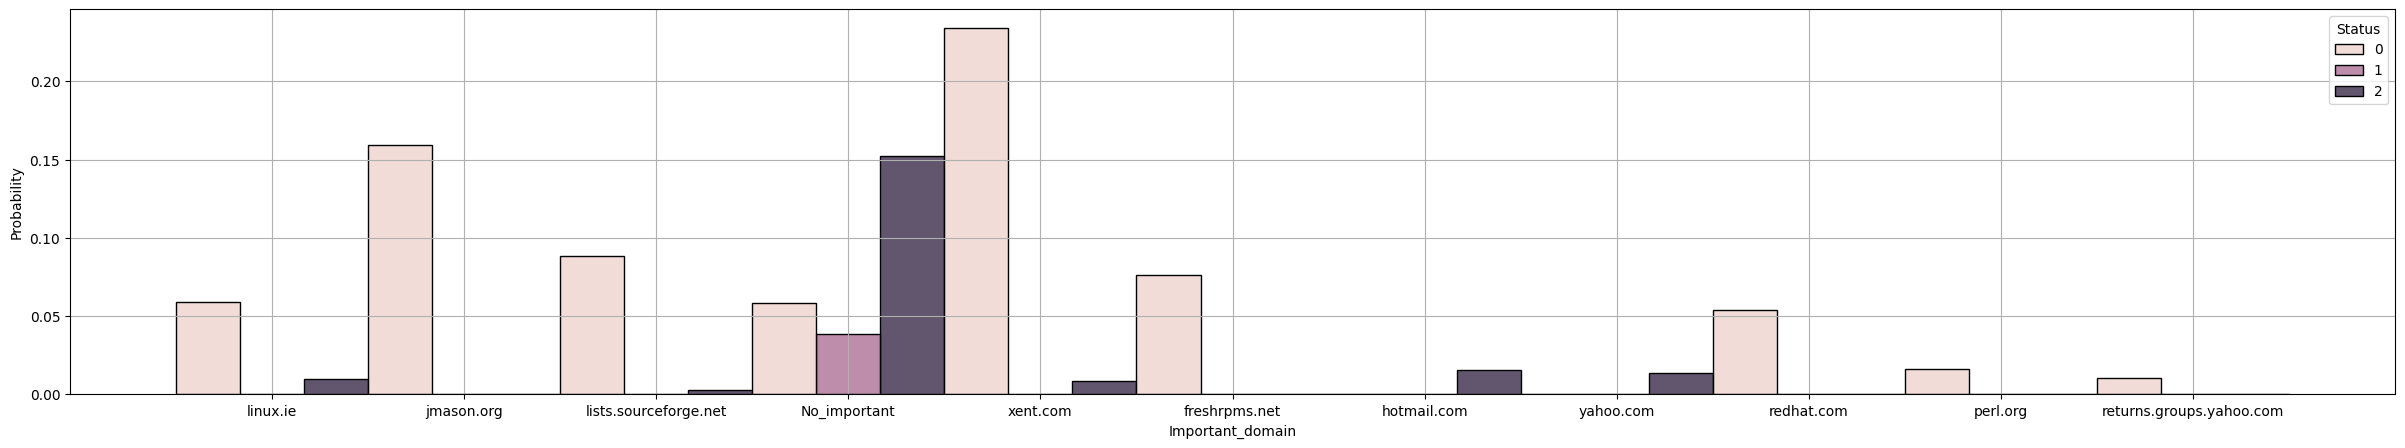

In [25]:
plt.figure(figsize=(30, 5))
sns.histplot(data=email_2, x="Important_domain", hue="Status", multiple="dodge", stat="probability")
plt.grid("on")
plt.show()

In [26]:
counted = email_2.groupby(["Important_domain","Status"]).size().reset_index(name="count")

In [27]:
counted.head()

,Important_domain,Status,count
0,No_important,0,623
1,No_important,1,410
2,No_important,2,1617
3,freshrpms.net,0,812
4,freshrpms.net,1,4


In [28]:
domains = counted.groupby("Important_domain")["count"].sum().reset_index(name="sum").merge(counted, how="right", on="Important_domain")

In [29]:
domains["count"] = domains["count"] / domains["sum"]

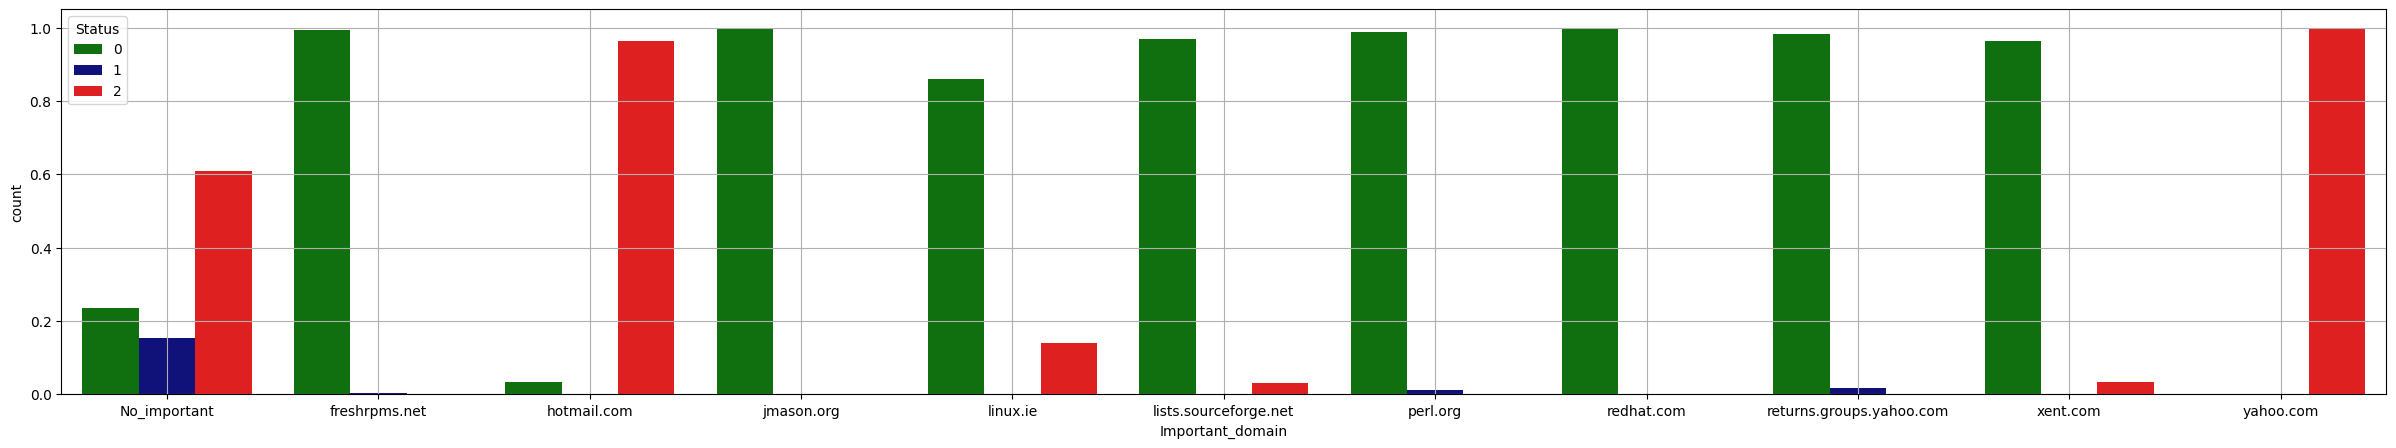

In [30]:
plt.figure(figsize=(30, 5))
sns.barplot(data=domains, x="Important_domain", hue="Status", y="count", palette=["green", "darkblue", "red"])
plt.grid("on")
plt.show()

Widzimy, że istotnie domena może mieć ogromne znaczenie, sprawdźmy dla większego zakresu domen

In [31]:
email_2.head()

,Status,Message,part_1,domain,count,Important_domain
0,0,ilug-admin@linux.ie,ilug-admin,linux.ie,732.0,linux.ie
1,0,rssfeeds@jmason.org,rssfeeds,jmason.org,1692.0,jmason.org
2,0,spamassassin-talk-admin@lists.sourceforge.net,spamassassin-talk-admin,lists.sourceforge.net,974.0,lists.sourceforge.net
3,2,jm@netnoteinc.com,jm,netnoteinc.com,NaN,No_important
4,0,fork-admin@xent.com,fork-admin,xent.com,2582.0,xent.com


In [32]:
email_2["domain"].isna().mean()

np.float64(0.061911930748965)

In [33]:
email_2["domain"] = np.where(email_2["domain"].isna(), "unknown", email_2["domain"])

In [64]:
threshold = 15
important_domains = email_2["domain"].value_counts()
important_domains = important_domains[important_domains > threshold]#0.01*X_train.shape[0]]

In [65]:
#important_domains, important_domains.shape

In [66]:
email_2 = email_2.merge(pd.DataFrame(important_domains).reset_index(),how="left", left_on="domain", right_on="domain")

In [67]:
email_2.drop(["count_x", "count_y"], axis=1, inplace=True)

In [68]:
email_2.head()

,Status,Message,part_1,domain,Important_domain
0,0,ilug-admin@linux.ie,ilug-admin,linux.ie,linux.ie
1,0,rssfeeds@jmason.org,rssfeeds,jmason.org,jmason.org
2,0,spamassassin-talk-admin@lists.sourceforge.net,spamassassin-talk-admin,lists.sourceforge.net,lists.sourceforge.net
3,2,jm@netnoteinc.com,jm,netnoteinc.com,No_important
4,0,fork-admin@xent.com,fork-admin,xent.com,xent.com


In [69]:
email_2 = email_2.merge(pd.DataFrame(important_domains).reset_index(),how="left", left_on="domain", right_on="domain")

In [70]:
email_2.head()

,Status,Message,part_1,domain,Important_domain,count
0,0,ilug-admin@linux.ie,ilug-admin,linux.ie,linux.ie,732.0
1,0,rssfeeds@jmason.org,rssfeeds,jmason.org,jmason.org,1692.0
2,0,spamassassin-talk-admin@lists.sourceforge.net,spamassassin-talk-admin,lists.sourceforge.net,lists.sourceforge.net,974.0
3,2,jm@netnoteinc.com,jm,netnoteinc.com,No_important,NaN
4,0,fork-admin@xent.com,fork-admin,xent.com,xent.com,2582.0


In [71]:
email_2["Important_domain"] = np.where(~email_2["count"].isna(), email_2["domain"], "No_important")

In [72]:
email_2.isna().mean()

Status              0.000000
Message             0.000000
part_1              0.000000
domain              0.000000
Important_domain    0.000000
count               0.123353
dtype: float64

In [73]:
important_domains.reset_index()["domain"][0]

'xent.com'

In [74]:
counted = email_2.groupby(["Important_domain","Status"]).size().reset_index(name="count")
domains = counted.groupby("Important_domain")["count"].sum().reset_index(name="sum").merge(counted, how="right", on="Important_domain")
domains["count"] = domains["count"] / domains["sum"]

In [75]:
domains.head()

,Important_domain,sum,Status,count
0,2ubh.com,19,0,1.000000
1,Flashmail.com,24,2,1.000000
2,No_important,1311,0,0.209001
3,No_important,1311,1,0.071701
4,No_important,1311,2,0.719298


In [76]:
domains["Important_domain"].unique().shape

(34,)

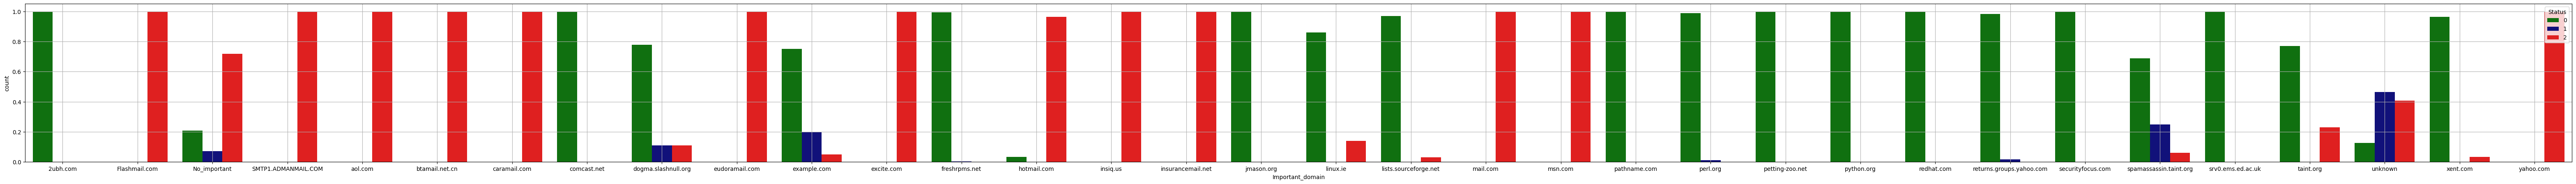

In [77]:
plt.figure(figsize=(80, 5))
sns.barplot(data=domains, x="Important_domain", hue="Status", y="count", palette=["green", "darkblue", "red"])
plt.grid("on")
plt.show()

## Wniosek 1: To czy dany email jest spamem, mocno zależy od domeny nadawcy - są takie domeny, gdzie 100% wysłanych maili to spam i odwrotnie

In [78]:
domains["Important_domain"].unique()

array(['2ubh.com', 'Flashmail.com', 'No_important', 'SMTP1.ADMANMAIL.COM',
       'aol.com', 'btamail.net.cn', 'caramail.com', 'comcast.net',
       'dogma.slashnull.org', 'eudoramail.com', 'example.com',
       'excite.com', 'freshrpms.net', 'hotmail.com', 'insiq.us',
       'insurancemail.net', 'jmason.org', 'linux.ie',
       'lists.sourceforge.net', 'mail.com', 'msn.com', 'pathname.com',
       'perl.org', 'petting-zoo.net', 'python.org', 'redhat.com',
       'returns.groups.yahoo.com', 'securityfocus.com',
       'spamassassin.taint.org', 'srv0.ems.ed.ac.uk', 'taint.org',
       'unknown', 'xent.com', 'yahoo.com'], dtype=object)

In [79]:
important_domains.index

Index(['xent.com', 'jmason.org', 'lists.sourceforge.net', 'freshrpms.net',
       'linux.ie', 'unknown', 'redhat.com', 'perl.org', 'hotmail.com',
       'yahoo.com', 'returns.groups.yahoo.com', 'aol.com', 'insiq.us',
       'msn.com', 'insurancemail.net', 'taint.org', 'petting-zoo.net',
       'securityfocus.com', 'btamail.net.cn', 'eudoramail.com',
       'SMTP1.ADMANMAIL.COM', 'excite.com', 'pathname.com', 'Flashmail.com',
       'caramail.com', 'python.org', 'mail.com', 'example.com', '2ubh.com',
       'dogma.slashnull.org', 'srv0.ems.ed.ac.uk', 'spamassassin.taint.org',
       'comcast.net'],
      dtype='object', name='domain')